# Getting the Weather Data

In [140]:
import requests
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

In [2]:
url = "https://dataset.api.hub.geosphere.at/v1/station/historical/tawes-v1-10min/metadata"

In [3]:
base_url ="https://dataset.api.hub.geosphere.at/v1"

## Getting all stations

In [96]:
datasets = requests.get(base_url + "/datasets")

In [97]:
datasets.json()

{'/grid/historical/apolis_short-v1-1d-100m': {'type': 'grid',
  'mode': 'historical',
  'response_formats': ['geojson', 'netcdf'],
  'url': 'https://dataset.api.hub.geosphere.at/v1/grid/historical/apolis_short-v1-1d-100m'},
 '/timeseries/historical/apolis_short-v1-1d-100m': {'type': 'timeseries',
  'mode': 'historical',
  'response_formats': ['geojson', 'csv'],
  'url': 'https://dataset.api.hub.geosphere.at/v1/timeseries/historical/apolis_short-v1-1d-100m'},
 '/station/historical/histalp-v1-1y': {'type': 'station',
  'mode': 'historical',
  'response_formats': ['geojson', 'csv'],
  'url': 'https://dataset.api.hub.geosphere.at/v1/station/historical/histalp-v1-1y'},
 '/grid/historical/inca-v1-1h-1km': {'type': 'grid',
  'mode': 'historical',
  'response_formats': ['geojson', 'netcdf'],
  'url': 'https://dataset.api.hub.geosphere.at/v1/grid/historical/inca-v1-1h-1km'},
 '/timeseries/historical/inca-v1-1h-1km': {'type': 'timeseries',
  'mode': 'historical',
  'response_formats': ['geojson'

In [103]:
stations = requests.get(base_url + "/station/historical/klima-v2-1h/metadata")

In [40]:
stations.json()

{'stations': [{'type': 'COMBINED',
   'id': 1,
   'group_id': None,
   'name': 'Aflenz',
   'state': 'Steiermark',
   'lat': 47.54594,
   'lon': 15.24069,
   'altitude': 783.2,
   'valid_from': '1983-05-01T00:00:00+00:00',
   'valid_to': '2100-12-31T00:00:00+00:00',
   'has_sunshine': True,
   'has_global_radiation': True,
   'is_active': True},
  {'type': 'COMBINED',
   'id': 2,
   'group_id': None,
   'name': 'Aigen im Ennstal',
   'state': 'Steiermark',
   'lat': 47.53278,
   'lon': 14.13826,
   'altitude': 641.0,
   'valid_from': '1993-02-01T00:00:00+00:00',
   'valid_to': '2100-12-31T00:00:00+00:00',
   'has_sunshine': True,
   'has_global_radiation': True,
   'is_active': True},
  {'type': 'COMBINED',
   'id': 3,
   'group_id': None,
   'name': 'Allentsteig',
   'state': 'Niederösterreich',
   'lat': 48.69083,
   'lon': 15.36694,
   'altitude': 598.8,
   'valid_from': '1992-10-01T00:00:00+00:00',
   'valid_to': '2100-12-31T00:00:00+00:00',
   'has_sunshine': True,
   'has_global_

In [168]:
stmk = []
sbg = []
w = []
oe = []
inn = []

In [169]:
#Sorting stations by state
for station in stations.json()["stations"]:
    if station["state"] == "Tirol":
        inn.append(station)
    elif station["state"] == "Salzburg":
        sbg.append(station)
    elif station["state"] == "Oberösterreich":
        oe.append(station)
    elif station["state"] == "Wien":
        w.append(station)
    elif station["state"] == "Steiermark":
        stmk.append(station)

In [182]:
#Graz Universität/Heinrichstraße had 50% missing values. Searching for other stations in Graz
stat_graz = []
for stat in stmk:
    if "Graz" in stat["name"]:
        stat_graz.append(stat)

In [214]:
#Salzburg Freisaal had 100% missing values in Snow amount measurement
stat_sbg = []
for stat in sbg:
    if "Salzburg" in stat["name"]:
        stat_sbg.append(stat)

In [216]:
stat_sbg

[{'type': 'COMBINED',
  'id': 131,
  'group_id': None,
  'name': 'Salzburg Flughafen',
  'state': 'Salzburg',
  'lat': 47.78944,
  'lon': 13.00861,
  'altitude': 430.0,
  'valid_from': '1939-03-01T00:00:00+00:00',
  'valid_to': '2100-12-31T00:00:00+00:00',
  'has_sunshine': True,
  'has_global_radiation': False,
  'is_active': True},
 {'type': 'COMBINED',
  'id': 145,
  'group_id': None,
  'name': 'Salzburg Freisaal',
  'state': 'Salzburg',
  'lat': 47.79111,
  'lon': 13.05417,
  'altitude': 419.0,
  'valid_from': '1987-01-01T00:00:00+00:00',
  'valid_to': '2100-12-31T00:00:00+00:00',
  'has_sunshine': True,
  'has_global_radiation': True,
  'is_active': True},
 {'type': 'INDIVIDUAL',
  'id': 6300,
  'group_id': 131,
  'name': 'Salzburg Flughafen',
  'state': 'Salzburg',
  'lat': 47.78944,
  'lon': 13.00861,
  'altitude': 430.0,
  'valid_from': '1933-09-01T00:00:00+00:00',
  'valid_to': '2100-12-31T00:00:00+00:00',
  'has_sunshine': True,
  'has_global_radiation': False,
  'is_active':

Searched for weather stations in austrias biggest citys because they will have data that impacts many people thus probably being most corellated to the austrian average energy consumption 

In [228]:
station_graz = "Graz Thalerhof Flughafen"
station_sbg = "Salzburg Freisaal"
staion_oö = "Linz Stadt"
station_inn = "Innsbruck Universität"
station_w = "Wien Hohe Warte"

In [229]:
stationen = [station_graz, station_sbg, staion_oö, station_inn, station_w]

In [230]:
stationen

['Graz Thalerhof Flughafen',
 'Salzburg Freisaal',
 'Linz Stadt',
 'Innsbruck Universität',
 'Wien Hohe Warte']

In [231]:
stadt_und_ids = {}
for station in stationen:
    stadt_und_ids[station] = []

In [232]:
for station in stations.json()["stations"]:
    if station["name"] in stationen:
        stadt_und_ids[station["name"]].append(station["id"])

In [233]:
stadt_und_ids

{'Graz Thalerhof Flughafen': [16400],
 'Salzburg Freisaal': [145, 6304, 6305],
 'Linz Stadt': [56, 3202],
 'Innsbruck Universität': [39, 11801, 11803],
 'Wien Hohe Warte': [105, 5901, 5904]}

## Getting the hourly Data for each relevant station from 2019-2025

In [100]:
metadata = requests.get(base_url + "/station/historical/klima-v2-1h/metadata")

The Metadata Resonse contains all the information: stations, features...

In [102]:
metadata.json()["parameters"]

[{'name': 'cglo',
  'long_name': 'Globalstrahlung Mittelwert',
  'description': 'Globalstrahlung, kalibrierter Stunden-Mittelwert',
  'unit': 'W/m²'},
 {'name': 'cglo_flag',
  'long_name': 'Qualitätsflag für Globalstrahlung Mittelwert',
  'description': 'Qualitätsflag für Globalstrahlung, kalibrierter Stunden-Mittelwert',
  'unit': 'code',
  'code_list_ref': 'q21'},
 {'name': 'dd',
  'long_name': 'Windrichtung 360° Mittelwert',
  'description': 'Windrichtung [360°], vektorieller Stunden-Mittelwert',
  'unit': '°'},
 {'name': 'dd_flag',
  'long_name': 'Qualitätsflag für Windrichtung 360° Mittelwert',
  'description': 'Qualitätsflag für Windrichtung [360°], vektorieller Stunden-Mittelwert',
  'unit': 'code',
  'code_list_ref': 'q21'},
 {'name': 'ddx',
  'long_name': 'Windrichtung zur Spitzenböe',
  'description': 'Windrichtung der maximalen Windgeschwindigkeit (Spitzenböe), Stundenwert',
  'unit': '°'},
 {'name': 'ddx_flag',
  'long_name': 'Qualitätsflag für Windrichtung zur Spitzenböe',

## Beschreibung der Parameter:
"ff" : "Windgeschwindigkeit", 

"rr": "Niederschlag",  

"sh": "Gesamtschneehöhe", 

"so_h": "Sonnenscheindauer", 

"tl": "Lufttemperatur"

In [114]:
def get_station_data(station_id, start = "2019-01-01T00:00", end = "2025-09-30T23:00"):
    try:
        print("Fetching Data")
        response = requests.get("https://dataset.api.hub.geosphere.at/v1/station/historical/klima-v2-1h", 
                    params = {
                        "parameters": ["ff", "rr", "sh", "so_h", "tl"],
                        "start": start,
                        "end": end,
                        "station_ids": station_id
                            })
        print("Parsing Result")
        data = response.json()
        print("Transforming Results")
        timestamps = data["timestamps"]
        params = data["features"][0]["properties"]["parameters"]
        print("Creating Params Dict")
        params_dict = {k: v["data"] for k, v in params.items()}
        return timestamps, params_dict

    except Exception as e:
        print(e)

In [115]:
def create_data_frame(station_id, start = "2019-01-01T00:00", end = "2025-09-30T23:00"):
    timestamps, params_dict = get_station_data(station_id, start, end)
    print("Creating DataFrame")
    df = pd.DataFrame(params_dict, index = pd.to_datetime(timestamps))
    print("Success")
    return df

In [116]:
def save_data_frame(df, df_name):
    if not os.path.exists("./DataFrames"):
        os.makedirs("./DataFrames")
    df.to_csv(f"./DataFrames/{str(df_name)}.csv")

In [242]:
save_data_frame(create_data_frame(stadt_und_ids["Salzburg Freisaal"][0]), "Salzburg")

Fetching Data
Parsing Result
Transforming Results
Creating Params Dict
Creating DataFrame
Success


In [249]:
for k, v in stadt_ids.items():
    print(k)
    save_data_frame(create_data_frame(v[0]), k)
    print(f"Successfully saved Data_Frame for {k}")

Graz
Fetching Data
Parsing Result
Transforming Results
Creating Params Dict
Creating DataFrame
Success
Successfully saved Data_Frame for Graz
Salzburg
Fetching Data
Parsing Result
Transforming Results
Creating Params Dict
Creating DataFrame
Success
Successfully saved Data_Frame for Salzburg
Linz
Fetching Data
Parsing Result
Transforming Results
Creating Params Dict
Creating DataFrame
Success
Successfully saved Data_Frame for Linz
Innsbruck
Fetching Data
Parsing Result
Transforming Results
Creating Params Dict
Creating DataFrame
Success
Successfully saved Data_Frame for Innsbruck
Wien
Fetching Data
Parsing Result
Transforming Results
Creating Params Dict
Creating DataFrame
Success
Successfully saved Data_Frame for Wien


## Exploring the Data. Handling NAN values and cleaning the Dataframes

In [324]:
def prepare_data_frame(df):
    df = df.rename(columns = {"Unnamed: 0": "DateUTC"})
    df["DateUTC"] = pd.to_datetime(df["DateUTC"])
    df = df.set_index("DateUTC")
    if "sh" in df.columns:
        df = df.drop(columns=["sh"])
    return df

1. Daten Exploren: Missing Values plotten
2. Daten brauchbar machen: Nan bei Schneefall => 0. Bei anderen rolling_mean...

In [340]:
Wien = prepare_data_frame(pd.read_csv("./DataFrames/Wien.csv"))
Salzburg = prepare_data_frame(pd.read_csv("./DataFrames/Salzburg.csv"))
Graz = prepare_data_frame(pd.read_csv("./DataFrames/Graz.csv"))
Innsbruck = prepare_data_frame(pd.read_csv("./DataFrames/Innsbruck.csv"))
Linz = prepare_data_frame(pd.read_csv("./DataFrames/Linz.csv"))

In [259]:
cities = [Wien, Salzburg, Graz, Innsbruck, Linz]

In [260]:
city_names = ["Wien", "Salzburg", "Graz", "Innsbruck", "Linz"]

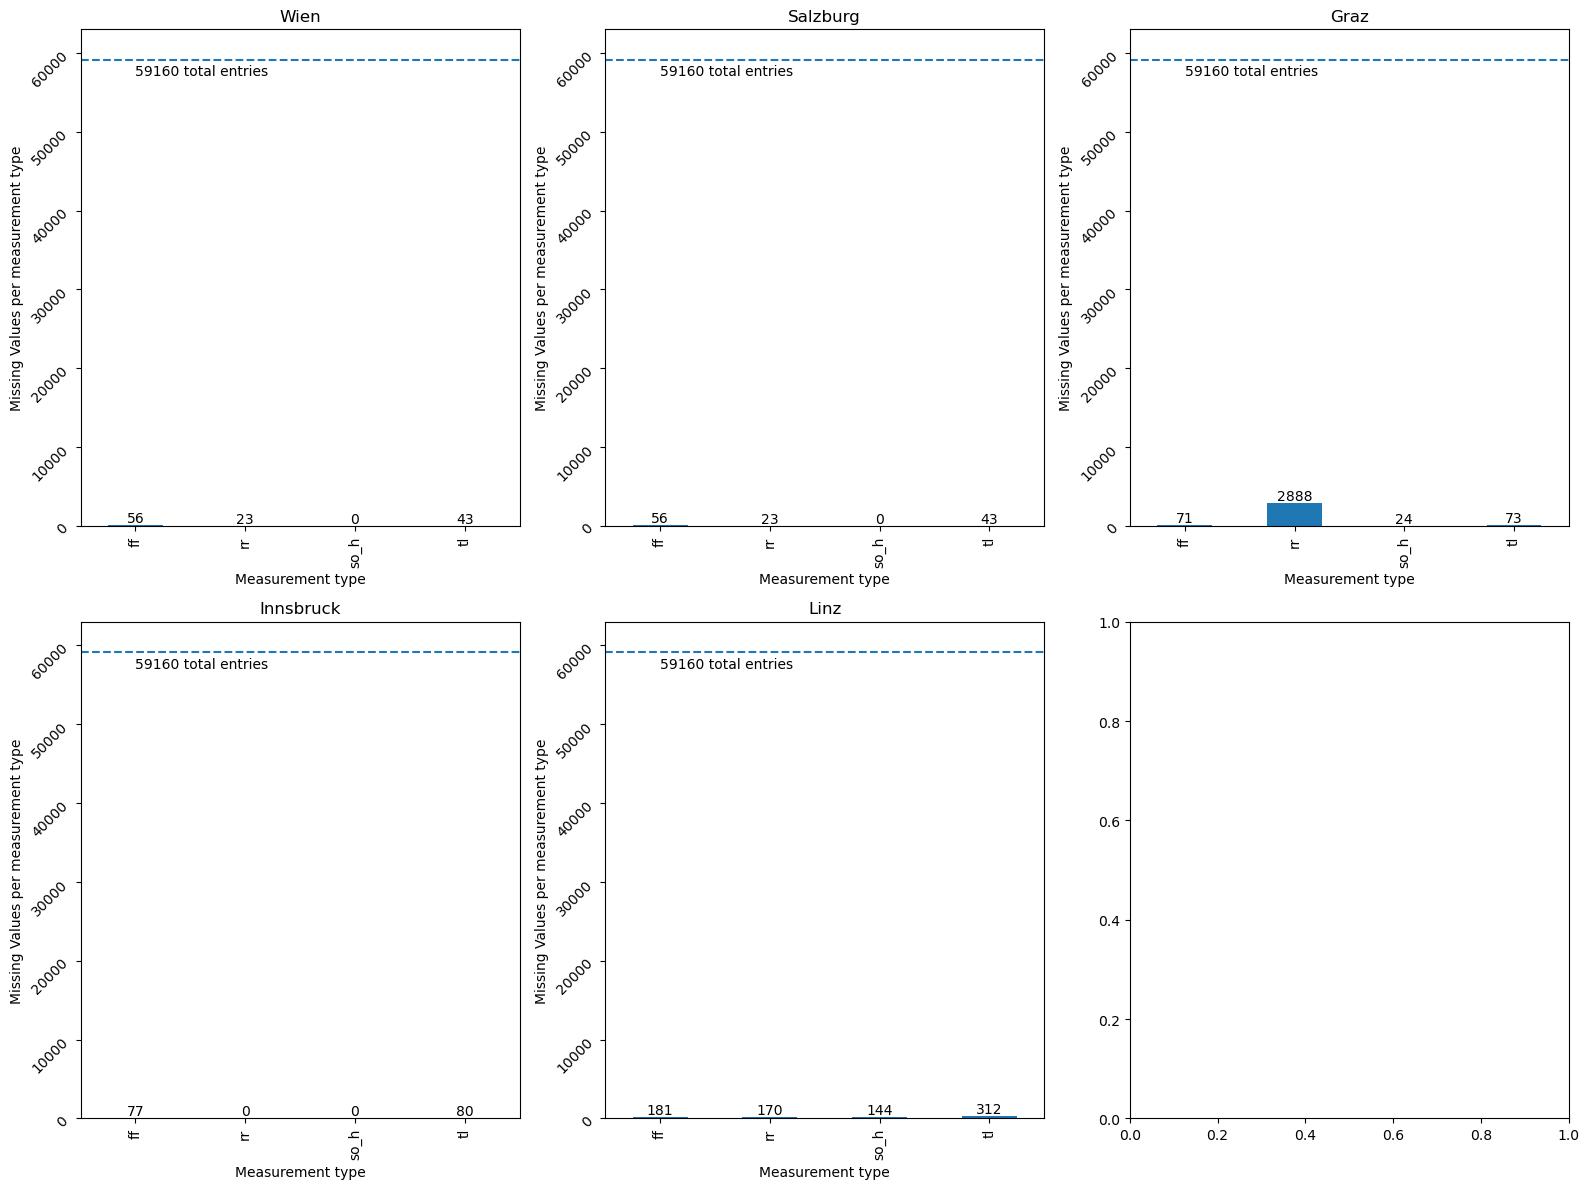

In [270]:
plt.subplots(2, 3, figsize = (16, 12))
for i, city in enumerate(cities):
    plt.subplot(2, 3, i+1)
    ax = city.isna().sum().plot(kind = "bar")
    for container in ax.containers:
        ax.bar_label(container, fmt="%.f")
    plt.title(city_names[i])
    plt.axhline(len(city), 0,  linestyle = "--")
    plt.text(0, len(city)-2000, f"{len(city)} total entries")
    plt.xlabel("Measurement type")
    plt.ylabel("Missing Values per measurement type")
    plt.tick_params("y", rotation = 45)
    plt.tight_layout()
    plt.ylim(0, 63000)

## Handling Missing Values

In [338]:
def handle_missing_inputs(df):
    df["so_h"] = df["so_h"].fillna(df["so_h"].shift(24))
    df["ff"] = df["ff"].fillna(
        pd.concat([df["ff"].shift(24), df["ff"].shift(1), df["ff"].shift(-24), df["ff"].shift(-1)], axis = 1).mean(axis = 1)
    )
    return df

In [343]:
handle_missing_inputs(Linz).isna().sum()

ff        0
rr      170
so_h     48
tl      312
dtype: int64

In [348]:
Wien[Wien["rr"].isna() == True]

,ff,rr,so_h,tl
DateUTC,,,,
2019-05-21 21:00:00+00:00,0.566667,NaN,0.0,NaN
2019-05-21 22:00:00+00:00,0.650000,NaN,0.0,NaN
2019-05-21 23:00:00+00:00,0.200000,NaN,0.0,NaN
2019-05-22 00:00:00+00:00,0.450000,NaN,0.0,NaN
2019-05-22 01:00:00+00:00,0.600000,NaN,0.0,NaN
2019-05-22 02:00:00+00:00,0.500000,NaN,0.0,NaN
2019-05-22 03:00:00+00:00,0.450000,NaN,0.0,NaN
2019-05-22 04:00:00+00:00,0.350000,NaN,0.0,NaN
2019-05-22 05:00:00+00:00,0.200000,NaN,0.0,NaN
